# Fake News Detection — Full Pipeline
### Steps covered: Upload → Clean → Train → Export model.pkl

## STEP 1 — Upload & Extract Dataset
Run this cell, then use the file picker to upload `WELFake_Dataset_csv.zip`

In [1]:
from google.colab import files
files.upload()  # upload ONLY kaggle.json here (tiny file, instant)

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ameenahsa","key":"f2230316a03f4c0d9f7f33abe0e53c99"}'}

In [2]:
import os, zipfile

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

os.system('pip install kaggle -q')
os.system('kaggle datasets download -d saurabhshahane/fake-news-classification')

with zipfile.ZipFile('fake-news-classification.zip', 'r') as z:
    z.extractall('.')

print(os.listdir('.'))  # you should see WELFake_Dataset.csv here

['.config', 'fake-news-classification.zip', 'WELFake_Dataset.csv', 'sample_data']


## STEP 2 — Load & Inspect

In [3]:
import pandas as pd

df = pd.read_csv('WELFake_Dataset.csv')

print('Shape:', df.shape)
print()
print('Label distribution (0=Real, 1=Fake):')
print(df['label'].value_counts())
print()
print('Sample rows:')
df.head(3)

Shape: (72134, 4)

Label distribution (0=Real, 1=Fake):
label
1    37106
0    35028
Name: count, dtype: int64

Sample rows:


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1


## STEP 3 — Clean Text Data

In [4]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()                              # lowercase
    text = re.sub(r'https?://\S+', '', text)         # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)             # remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()         # remove extra spaces
    words = text.split()
    words = [w for w in words if w not in stop_words]  # remove stopwords
    return ' '.join(words)

# Combine title + text for richer features
df['content'] = (df['title'].fillna('') + ' ' + df['text'].fillna(''))
df['content'] = df['content'].apply(clean_text)

# Drop rows where content ended up empty
df = df[df['content'].str.strip() != ''].reset_index(drop=True)

print(f'Clean done! Rows remaining: {len(df)}')
print()
print('Sample cleaned text:')
print(df['content'][0][:300])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Clean done! Rows remaining: 72080

Sample cleaned text:
law enforcement high alert following threats cops whites blacklivesmatter fyf terrorists video comment expected barack obama members fyf fukyoflag blacklivesmatter movements called lynching hanging white people cops encouraged others radio show tuesday night turn tide kill white people cops send mes


## STEP 4 — TF-IDF Vectorization

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df['content']
y = df['label']

# Split BEFORE vectorizing to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)   # fit only on train!
X_test_vec  = vectorizer.transform(X_test)         # transform test

print(f'Train size : {X_train_vec.shape}')
print(f'Test  size : {X_test_vec.shape}')

Train size : (57664, 50000)
Test  size : (14416, 50000)


## STEP 5 — Train Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = LogisticRegression(max_iter=1000, C=1.0)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc * 100:.2f}%')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

Accuracy: 96.15%

Classification Report:
              precision    recall  f1-score   support

        Real       0.97      0.95      0.96      7006
        Fake       0.96      0.97      0.96      7410

    accuracy                           0.96     14416
   macro avg       0.96      0.96      0.96     14416
weighted avg       0.96      0.96      0.96     14416



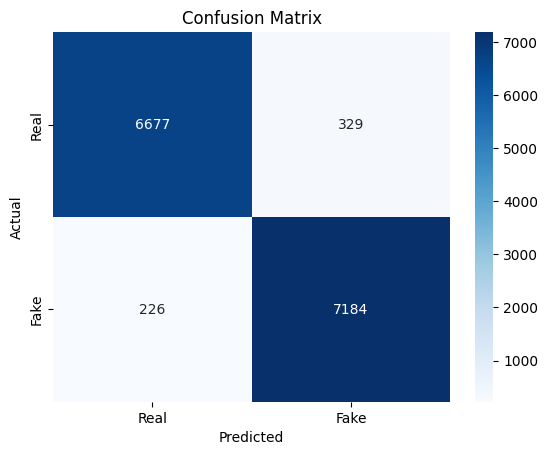

In [7]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## STEP 6 — Export model.pkl & vectorizer.pkl

In [8]:
import joblib

joblib.dump(model,      'model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

print('Saved: model.pkl')
print('Saved: vectorizer.pkl')

Saved: model.pkl
Saved: vectorizer.pkl


In [10]:
# Download both files to your computer
from google.colab import files
files.download('model.pkl')
files.download('vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## STEP 7 — Quick Test (sanity check before handing off)

In [11]:
def predict_news(text):
    cleaned = clean_text(text)
    vec     = vectorizer.transform([cleaned])
    pred    = model.predict(vec)[0]
    prob    = model.predict_proba(vec)[0]
    label   = 'FAKE' if pred == 1 else 'REAL'
    conf    = prob[pred] * 100
    print(f'Prediction : {label}')
    print(f'Confidence : {conf:.1f}%')

# Test with a sample
predict_news("Scientists discover new vaccine that cures all diseases overnight")
print()
predict_news("The Federal Reserve raised interest rates by 0.25 percentage points on Wednesday")

Prediction : FAKE
Confidence : 79.0%

Prediction : REAL
Confidence : 66.5%
